In [ ]:
# 1. Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
# 2. Load the dataset
df = pd.read_csv('/content/creditcard 2.csv')

print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [ ]:
# 3. Drop 'Time' column (it doesn't add much information)
df = df.drop(columns=['Time'])

# 4. Check missing/null values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
# 5. Feature Engineering
# 5.1. Log-transform 'Amount' to reduce skewness
df['Amount_log'] = np.log1p(df['Amount'])

# 5.2. Binning 'Amount' into categories
df['Amount_bin'] = pd.qcut(df['Amount'], q=5, labels=False)

# 5.3. Create 'V_Magnitude' as the sum of absolute V1-V28 values
v_features = [f'V{i}' for i in range(1, 29)]
df['V_magnitude'] = df[v_features].abs().sum(axis=1)

In [ ]:
# 5.4. Create outlier flags for extreme V values
for v in v_features:
    mean = df[v].mean()
    std = df[v].std()
    df[f'{v}_outlier'] = ((df[v] > (mean + 3*std)) | (df[v] < (mean - 3*std))).astype(int)


In [ ]:
# 6. Scaling 'Amount' separately
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])


In [ ]:
# 7. Final feature selection
# Drop original 'Amount' now that we have 'Amount_log' and 'Amount_scaled'
df = df.drop(columns=['Amount'])

In [ ]:
# 8. Prepare input features (X) and target (y)
X = df.drop(columns=['Class'])
y = df['Class']

# 9. Train-Test Split (before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

print(f"Training Data Shape Before SMOTE: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")


Training Data Shape Before SMOTE: (199364, 60)
Testing Data Shape: (85443, 60)


In [ ]:

# 10. Handle imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Training Data Shape After SMOTE: {X_train_res.shape}")

Training Data Shape After SMOTE: (398040, 60)


<ipython-input-12-99705380145a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='magma')


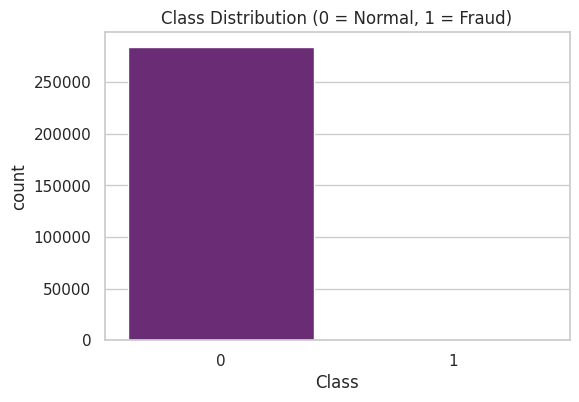

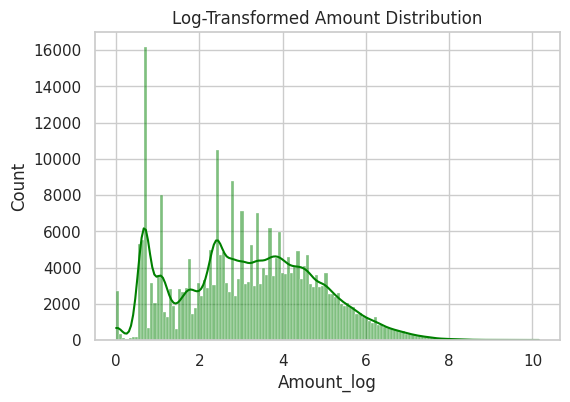

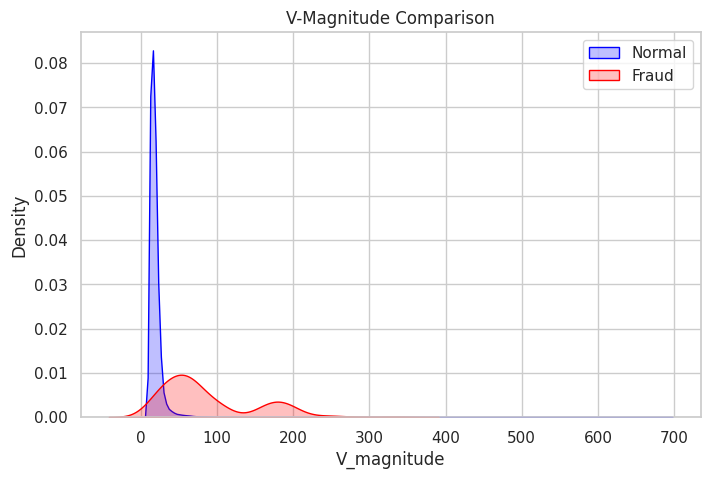

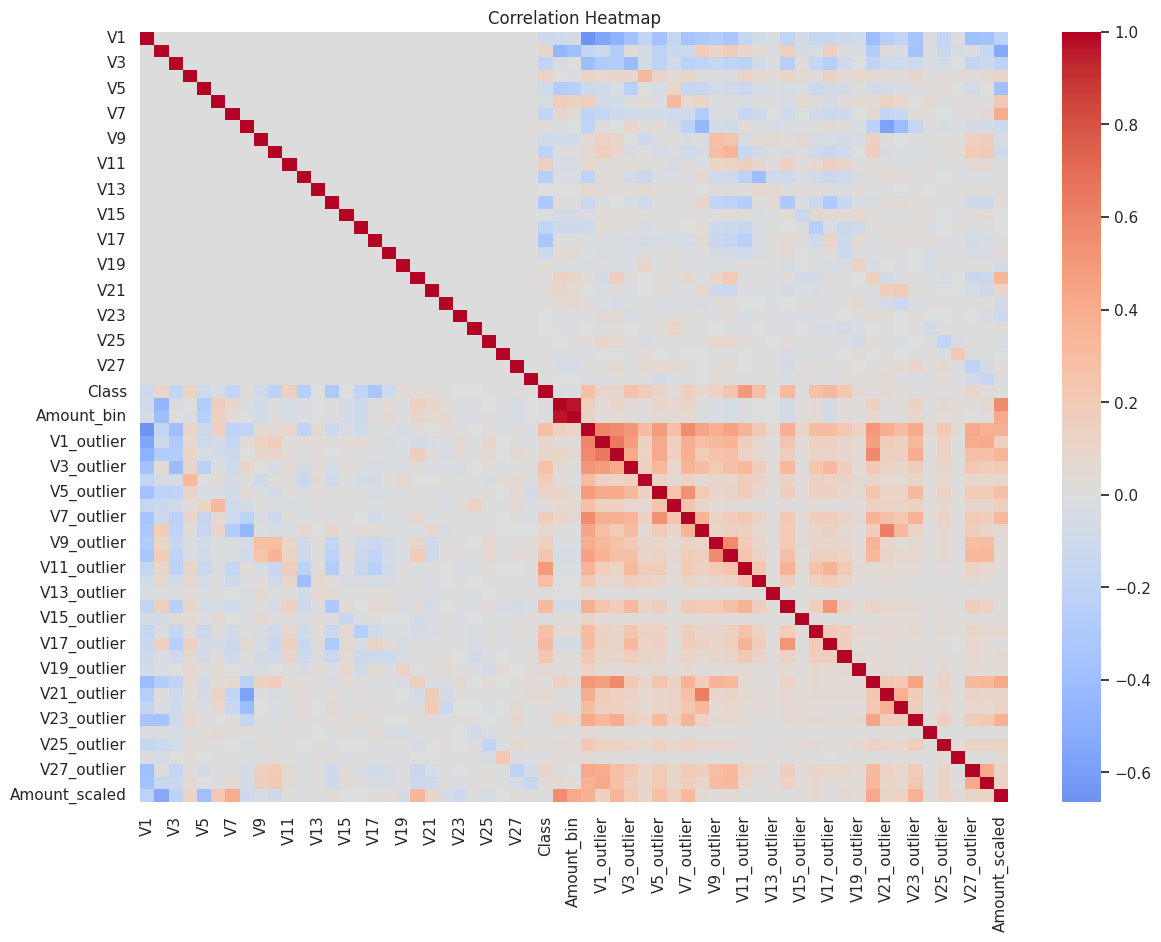

In [ ]:
# ==================== Advanced EDA ====================

# 1. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='magma')
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.savefig('eda_class_distribution_advanced.png')
plt.show()

# 2. Amount log distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['Amount_log'], kde=True, color='green')
plt.title('Log-Transformed Amount Distribution')
plt.savefig('eda_amount_log_distribution.png')
plt.show()

# 3. V_Magnitude distribution for Fraud vs Normal
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['Class'] == 0]['V_magnitude'], label='Normal', fill=True, color='blue')
sns.kdeplot(df[df['Class'] == 1]['V_magnitude'], label='Fraud', fill=True, color='red')
plt.title('V-Magnitude Comparison')
plt.legend()
plt.savefig('eda_v_magnitude_distribution.png')
plt.show()

# 4. Heatmap of Correlations
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('eda_correlation_heatmap_advanced.png')
plt.show()


In [ ]:
# ==================== Part 2: Model Training and Evaluation ====================

# Libraries needed
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Standardize Features (Scaling is important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

# 2. Logistic Regression
lr_model = LogisticRegression(max_iter=100, random_state=42)
lr_model.fit(X_train_res_scaled, y_train_res)
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test)

# 4. Linear SVM
svm_model = LinearSVC(max_iter=1000, random_state=42)
svm_model.fit(X_train_res_scaled, y_train_res)
y_pred_svm = svm_model.predict(X_test_scaled)

# Collect results
from sklearn.metrics import confusion_matrix

model_results = {}

for model_name, y_pred in zip(['Random Forest', 'Logistic Regression', 'XGBoost', 'SVM'],
                              [y_pred_rf, y_pred_lr, y_pred_xgb, y_pred_svm]):
    model_results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }

# Create comparison DataFrame
results_df = pd.DataFrame(model_results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']]
print(results_df.sort_values('F1 Score', ascending=False))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


                     Accuracy Precision    Recall  F1 Score
Random Forest        0.999473  0.887218  0.797297  0.839858
XGBoost              0.999403  0.825503  0.831081  0.828283
SVM                  0.981684  0.074474  0.837838   0.13679
Logistic Regression  0.980607  0.072036  0.858108  0.132915


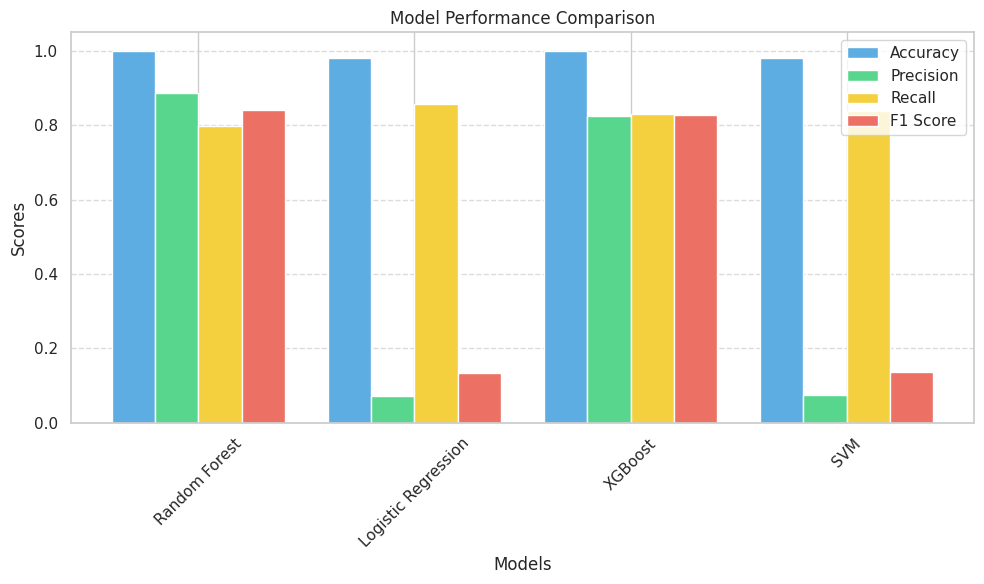

In [ ]:
# ==================== Model Performance Visualization ====================

# Bar chart for Accuracy, Precision, Recall, F1 Score
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#5DADE2', '#58D68D', '#F4D03F', '#EC7063']

# Plot
plt.figure(figsize=(10, 6))
bar_width = 0.2
index = np.arange(len(results_df))

for i, metric in enumerate(metrics):
    plt.bar(index + i*bar_width, results_df[metric], bar_width, label=metric, color=colors[i])

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(index + 1.5*bar_width, results_df.index, rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png')
plt.show()


In [ ]:
# ==================== Part 3: Deep Learning Model (ANN) ====================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# 1. Prepare data
# (We already scaled X_train_res and X_test in Part 2)
# X_train_res_scaled, X_test_scaled

# 2. Build ANN Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 3. Compile Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train Model
history = model.fit(
    X_train_res_scaled, y_train_res,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

# 5. Predict on Test Data
y_pred_dl_probs = model.predict(X_test_scaled)
y_pred_dl = (y_pred_dl_probs > 0.5).astype(int).reshape(-1)

# 6. Evaluate
print("🔍 Deep Learning Model:\n")
print(classification_report(y_test, y_pred_dl))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9153 - loss: 0.2150 - val_accuracy: 0.9580 - val_loss: 0.0919
Epoch 2/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9799 - loss: 0.0556 - val_accuracy: 0.9835 - val_loss: 0.0368
Epoch 3/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9890 - loss: 0.0323 - val_accuracy: 0.9957 - val_loss: 0.0155
Epoch 4/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accuracy: 0.9974 - val_loss: 0.0129
Epoch 5/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9960 - loss: 0.0147 - val_accuracy: 0.9999 - val_loss: 0.0056
Epoch 6/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.9998 - val_loss: 0.0053
Epoch 7/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9974 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 8/10
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9979 - loss: 0.0084 - val_accuracy: 1.

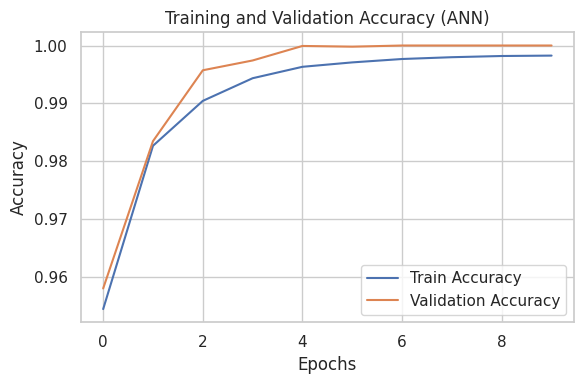

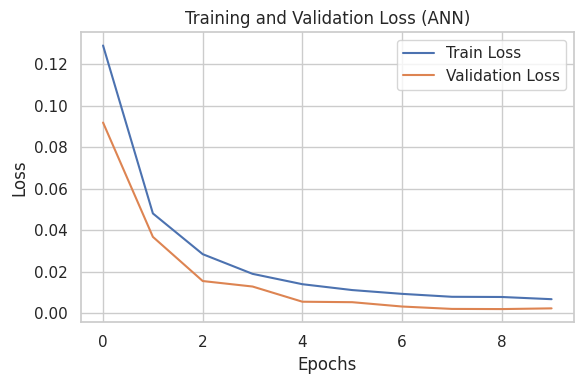

In [ ]:
# ==================== Training Curves (Accuracy and Loss) ====================

history_dict = history.history

# Accuracy plot
plt.figure(figsize=(6, 4))
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (ANN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('ann_accuracy_plot.png')
plt.show()

# Loss plot
plt.figure(figsize=(6, 4))
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (ANN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('ann_loss_plot.png')
plt.show()


        Predicted_Probability Risk_Level  Actual_Label
186882                   0.00   Low Risk             0
165754                   0.00   Low Risk             0
235285                   0.00   Low Risk             0
101271                   0.00   Low Risk             0
5832                     0.00   Low Risk             0
253774                   0.00   Low Risk             0
113630                   0.00   Low Risk             0
230121                   0.00   Low Risk             0
282997                   0.01   Low Risk             0
26831                    0.00   Low Risk             0

Risk Level Distribution:
 Risk_Level
Low Risk       85309
High Risk        108
Medium Risk       26
Name: count, dtype: int64


<ipython-input-26-d1f57df361b4>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=risk_segmentation_df, palette='coolwarm', order=['High Risk', 'Medium Risk', 'Low Risk'])


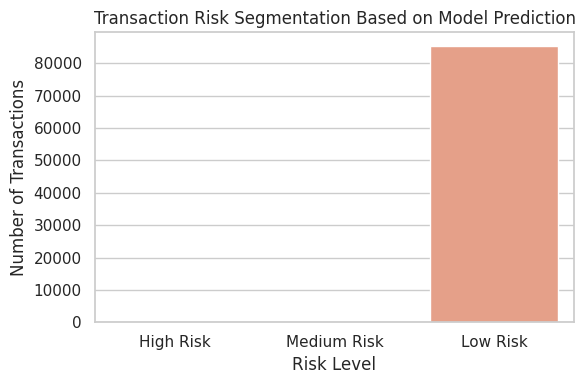

In [ ]:
# ==================== Part A: Risk Segmentation ====================

# Predict probabilities on the entire test set
y_pred_probs_rf = rf_model.predict_proba(X_test)[:, 1]  # Probability of Fraud (Class 1)

# Create Risk Levels
risk_levels = []

for prob in y_pred_probs_rf:
    if prob >= 0.8:
        risk_levels.append('High Risk')
    elif prob >= 0.5:
        risk_levels.append('Medium Risk')
    else:
        risk_levels.append('Low Risk')

# Create a Risk Segmentation DataFrame
risk_segmentation_df = X_test.copy()
risk_segmentation_df['Predicted_Probability'] = y_pred_probs_rf
risk_segmentation_df['Risk_Level'] = risk_levels
risk_segmentation_df['Actual_Label'] = y_test

# Show some examples
print(risk_segmentation_df[['Predicted_Probability', 'Risk_Level', 'Actual_Label']].head(10))

# 📊 Risk Level Counts
risk_counts = risk_segmentation_df['Risk_Level'].value_counts()
print("\nRisk Level Distribution:\n", risk_counts)

# 📊 Plot Risk Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Level', data=risk_segmentation_df, palette='coolwarm', order=['High Risk', 'Medium Risk', 'Low Risk'])
plt.title('Transaction Risk Segmentation Based on Model Prediction')
plt.ylabel('Number of Transactions')
plt.xlabel('Risk Level')
plt.tight_layout()
plt.savefig('risk_segmentation_plot.png')
plt.show()


        Feature  Importance
13          V14    0.170939
3            V4    0.102862
44  V14_outlier    0.079645
30  V_magnitude    0.078648
9           V10    0.073281
16          V17    0.061073
10          V11    0.048321
42  V12_outlier    0.044927
11          V12    0.042074
47  V17_outlier    0.028857


<ipython-input-27-47155222fa51>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(10), palette='viridis')


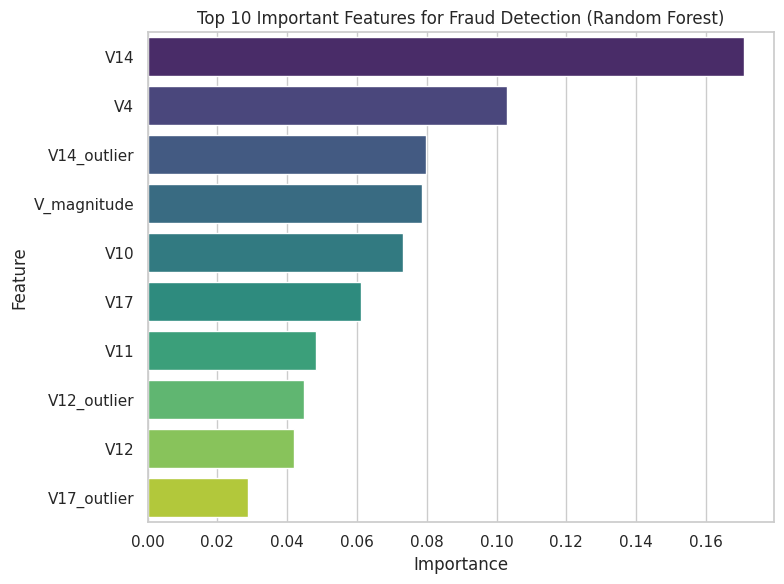

In [ ]:
# ==================== Part B: Feature Importance (Random Forest) ====================

# Get feature importances from trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a sorted DataFrame
feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

# Show Top 10 important features
print(feat_importance_df.head(10))

# 📊 Plot Top 10 Important Features
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(10), palette='viridis')
plt.title('Top 10 Important Features for Fraud Detection (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance_plot.png')
plt.show()


In [ ]:
# ==================== Fraud Alert System ====================

def fraud_alert_system(risk_df, threshold=0.80):
    """
    Scan risk_df and generate alerts for High Risk transactions based on probability threshold.
    """
    alerts = []

    # Go through each transaction
    for idx, row in risk_df.iterrows():
        prob = row['Predicted_Probability']
        if prob >= threshold:
            alert_message = f"🚨 ALERT: High Risk Transaction Detected! [ID: {idx}] | Fraud Probability: {round(prob*100, 2)}%"
            alerts.append(alert_message)

    return alerts

# Run Fraud Alert System
alerts = fraud_alert_system(risk_segmentation_df)

# Show Alerts
print(f"Total High Risk Alerts Generated: {len(alerts)}\n")
for alert in alerts[:10]:  # Show first 10 alerts
    print(alert)


Total High Risk Alerts Generated: 108

🚨 ALERT: High Risk Transaction Detected! [ID: 43204] | Fraud Probability: 99.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 229712] | Fraud Probability: 98.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 218442] | Fraud Probability: 100.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 153823] | Fraud Probability: 100.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 42549] | Fraud Probability: 97.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 47802] | Fraud Probability: 91.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 124115] | Fraud Probability: 94.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 238222] | Fraud Probability: 90.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 42769] | Fraud Probability: 100.0%
🚨 ALERT: High Risk Transaction Detected! [ID: 106998] | Fraud Probability: 97.0%
